In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
#заметим, что тут TPMки не указанs
with open("GRCh38_chr1.fa", "r") as file:
    fasta_data = file.readlines()

fasta_data = fasta_data[1:]
fasta_data = ''.join(fasta_data)

In [3]:
print(fasta_data[100000:100600])
print(len(fasta_data))
print(fasta_data[100001])

TGCTCATTCATTCCAGTTTTTAAAAATTCATCTTTATCC
AGGAACCTCGCTTCTAGAAAAGTCATACAGGTGCTTCCAGGAGGCTACATGGGCACCCAT
ATTTTTCTAGCCACTTTCATTAGACCAATGCAGCAGAGAAGAAAAGCCTCAATAATTATT
ATGACATGGCATGTTAGGATACCAAGTAAATTGCATTTGTAAAATGTGATTTTCTGTTGG
TGTTCACTTCAGCTCTACTGACATTTGGTAAGTATTATTGACTGACTGACTAACTAATGT
GGTCATTAGTCTTCATAAAGAAAGGCTCTCTACAAAAACGGAGGGATGCCCTTTTTCTGG
CATTTAATACGTAAGAAATTGCCTCCAATAGAAACCAGAGTTGCCTGATTACTATCAGCA
CAGGAGAAATGTATTAATGTGCCTTTCTAGTAACAGGTTTTTAGAAAGTCAAATATAAAC
AAATCTGTCTATTTGTGTGTGTGCATGTGGTAGTGGGGAGGGAAGAAAAAAGGAGGGGGA
GAGAAAGAGAAATAAGAACCAAGTTTATTATACTGTATTCAGGGGGAAAAAATTTTCCCA
AGGTCCTAACA
253105696
G


In [4]:
filename = 'NCBI_annotations.csv'
with open(filename, 'r', newline='') as csvfile:
    annotations = csvfile.readlines()

annotations = annotations[2:]

In [5]:
print(type(annotations[10].split(';')[1]))

<class 'str'>


In [6]:
lengths = []
for line in annotations:
    start = line.split(';')[1]
    stop = line.split(';')[2]
    leng = int(stop) - int(start)
    lengths.append(leng)

In [7]:
print(len(lengths))

5519


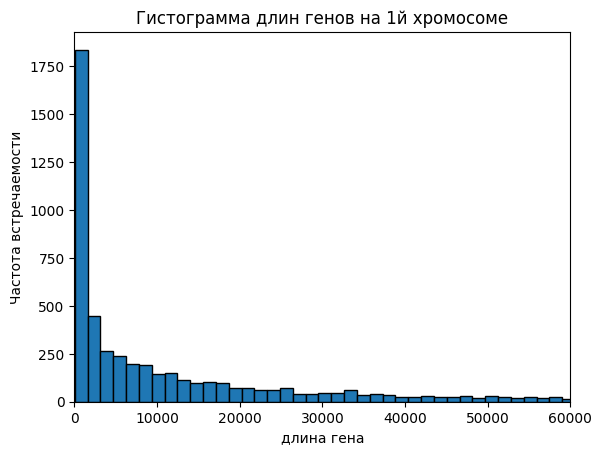

25-й процентиль: 862.0
50-й процентиль (медиана): 6035.0
97.5-й процентиль: 198928.6500000002


In [12]:
plt.hist(lengths, bins = 1000, edgecolor='black')  # bins - количество столбцов гистограммы

plt.title('Гистограмма длин генов на 1й хромосоме')
plt.xlabel('длина гена')
plt.ylabel('Частота встречаемости')
plt.xlim(0, 60000)
plt.show()


percentiles = np.percentile(lengths, [25, 50, 97.5])

print("25-й процентиль:", percentiles[0])
print("50-й процентиль (медиана):", percentiles[1])
print("97.5-й процентиль:", percentiles[2])

In [13]:
fake_lengths = np.random.randint(860, 190001, size = len(lengths))

In [14]:
print(fake_lengths[0:50])

[ 46991 100209  54251  12908 130654  71803  60438  47489  45381 171225
 144651  26913   8039 153923  45796 116837 163401  62158  78371  16442
  26750 141244 150920 129970 186014  10045  90082 189412 189177  49173
 163166 102348  45674  29138   7024 158342  35246  33612 147351  68797
   1083   3888  75939 140034 131959 179014 174540  11108  63677  75877]


In [15]:
filename = 'HEK293.TPM'
with open(filename, 'r', newline='') as file:
    tpm1 = file.readlines()
TPM1 = tpm1[1:]


filename = 'K562.TPM'
with open(filename, 'r', newline='') as file:
    tpm2 = file.readlines()
TPM2 = tpm2[1:]

filename = 'K562WHITE.TPM'
with open(filename, 'r', newline='') as file:
    tpm3 = file.readlines()
TPM3 = tpm3[1:]

In [16]:
full_tpm = TPM1 + TPM2 + TPM3
TPMs = []

for st in full_tpm:
    TPMs.append(float(st.split('\t')[1]))

In [17]:
assert(len(TPMs) == len(TPM1) + len(TPM2) + len(TPM3))
print(len(TPMs))

181563


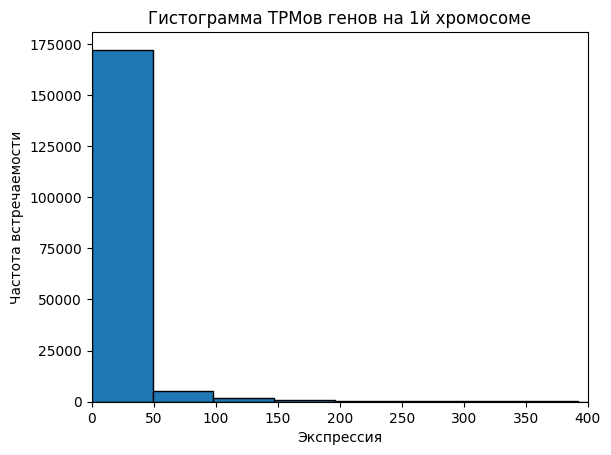

50-й процентиль (медиана): 0.0
97.5-й процентиль: 50.968999999999944


In [18]:
plt.hist(TPMs, bins = 1000, edgecolor='black')  # bins - количество столбцов гистограммы

plt.title('Гистограмма TPMoв генов на 1й хромосоме')
plt.xlabel('Экспрессия')
plt.ylabel('Частота встречаемости')
plt.xlim(0, 400)
plt.show()


percentiles = np.percentile(TPMs, [50, 95])

print("50-й процентиль (медиана):", percentiles[0])
print("97.5-й процентиль:", percentiles[1])

In [19]:
fake_tpms = np.random.randint(0, 50, size = len(lengths))

In [20]:
matrix = [fake_lengths, fake_tpms]
for i in range(20):
    print(matrix[0][i], " ", matrix[1][i])


46991   38
100209   8
54251   35
12908   39
130654   5
71803   44
60438   39
47489   5
45381   5
171225   14
144651   49
26913   46
8039   21
153923   9
45796   20
116837   23
163401   35
62158   25
78371   7
16442   42


In [21]:
fake_starts = [0] * len(fake_lengths)
amount = len(fake_lengths)
assert amount == len(fake_tpms)

for i in range(1, amount):
    fake_starts[i] = fake_starts[i-1]+fake_lengths[i-1]

In [22]:
def rotate(arr1, arr2):
    random_number = np.random.rand()  # Генерируем случайное число от 0 до 1
    multiplied_number = random_number * len(arr1)  # Умножаем на длину массива
    N = int(np.round(multiplied_number)) 

    rotated_arr1 = np.concatenate((arr1[-N:], arr1[:-N]))  # Используем concatenate для объединения срезов
    rotated_arr2 = np.concatenate((arr2[-N:], arr2[:-N]))  # Используем concatenate для объединения срезов
    
    return rotated_arr1, rotated_arr2

In [23]:
print(amount)

5519


In [25]:
print(fake_starts[:10])

[0, 46991, 147200, 201451, 214359, 345013, 416816, 477254, 524743, 570124]
[ 46991 100209  54251  12908 130654  71803  60438  47489  45381 171225]


Начиная отсюда, начнём жеска менять код чтобы сделать из этого модуль 

In [52]:
#вычисляем настоящее среднее значение экспрессии
main_mean = np.mean(fake_tpms)
main_disp = np.var(fake_tpms, ddof=1)
tpm_ring = fake_tpms
lengs_ring = fake_lengths

In [42]:
number_of_domains = amount//2
domain_coordinates = []
for i in range(1, len(fake_starts) - 1, 2):
    start = fake_starts[i]
    end = fake_starts[i + 1] - 1
    domain_coordinates.append([start, end])

In [43]:
print(domain_coordinates[0], domain_coordinates[1])

[46991, 147199] [201451, 214358]


In [44]:
#начинаем жоско крутить массив

fake_means = []  # Массив для хранения средних по циклическим перестановкам
fake_dispersions = []  # Массив для хранения дисперсий

def count_means(express, lenns):
    # Функция для вычисления средних значений внутри доменов и их дисперсий

    # Выполняем циклическую перестановку
    express, lenns = rotate(express, lenns)
    
    current_sum = 0  # Переменная для хранения текущей суммы значений
    count = 0  # Счетчик количества значений внутри текущего домена
    count0 = 0  # Начальный индекс текущего домена
    list_of_results = []  # Массив для хранения вычисленных средних значений
    list_of_dispersions = []  # Массив для хранения вычисленных дисперсий

    for i in range(number_of_domains):
        count = 0
        # Определяем значения внутри текущего домена
        for num in lenns:
            current_sum += num
            count += 1
            if current_sum >= domain_coordinates[i][1]:
               break  # Если текущая сумма значений внутри домена достигла его верхней границы, выходим из цикла
        current_domain = express[count0:count0+count]  # Выделяем текущий домен
        result = np.mean(current_domain)  # Вычисляем среднее значение внутри текущего домена

        gene_dispersions = []
        gene_dispersions.append(np.mean([(values - result) ** 2 for values in current_domain]))  # Вычисляем дисперсии для текущего гена
        domain_dispersion = np.mean([(values) ** 2 for values in gene_dispersions])  # Вычисляем общую дисперсию для домена

        count0 = count  # Обновляем начальный индекс текущего домена
        count = 0  # Сбрасываем счетчик

        list_of_results.append(result)  # Добавляем среднее значение текущего домена в массив результатов
        list_of_dispersions.append(domain_dispersion)  # Добавляем дисперсию текущего домена в массив дисперсий

    return list_of_results, list_of_dispersions


In [69]:
num_of_rotations = 10000

fake_means = []  # Массив для хранения средних по циклическим перестановкам
fake_dispersions = []  # Массив для хранения дисперсий
for i in range(num_of_rotations):
    results, dispersions = count_means(tpm_ring, lengs_ring)
    fake_means.append(results)
    fake_dispersions.append(dispersions)

In [70]:
means_for_rotations = []
disps_for_rotations = []
for j in range(110): 
    means_for_rotations.append(np.mean([inner_list[j] for inner_list in fake_means]))
    disps_for_rotations.append(np.mean([inner_list[j] for inner_list in fake_dispersions]))



In [71]:
means_for_all = np.mean(means_for_rotations)
disps_for_all = np.mean(disps_for_rotations)

fake_means = [[110 доменов],[110 доменов],[110 доменов], и так 10K раз]

теперь сделаем среднее по всем доменам 

In [72]:
def Gauss_criterium(mu1, mu2, sig1, sig2, n1, n2):
    z = (mu1 - mu2)/(((sig1**2)/n1 + (sig2)/n2)**0.05)
    return z

In [73]:
print(main_mean, means_for_all, main_disp, disps_for_all, amount, amount)
end_z = Gauss_criterium(main_mean, means_for_all, main_disp, disps_for_all, amount, amount)

print(end_z)

24.67838376517485 24.699668116161618 210.150440591371 17362.185251732364 5519 5519
-0.01886690713856348


In [74]:
z_100 = -0.946
z_1000 = 0.24
z_10K = -0.01886690713856348
#заебись